# HinDiff - Hindi Masked Diffusion Language Model

A **discrete diffusion model** trained purely on Hindi text.

| | |
|---|---|
| **Task** | Learn to iteratively unmask / denoise Hindi sentences |
| **Dataset** | Samanantar Hindi side — 300K sentences |
| **Model** | Bidirectional transformer, ~21M params |
| **Runtime** | ~22–28 min on T4 GPU |
| **Demo** | Infilling (fill blanks) + Generation (start from all-`[MASK]`) |

**Why diffusion instead of autoregressive?**
- Fills in the *middle* of a sentence naturally (infilling is trivial)
- Generates in any order — not locked to left-to-right
- Iterative refinement lets the model revise uncertain tokens

Make sure **Runtime → Change runtime type → T4 GPU** is selected before running.

In [2]:
# ── Cell 1: Install ──────────────────────────────────────────────────────────
!pip install -q transformers datasets accelerate tqdm sacrebleu matplotlib sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.8 MB/s eta 0:00:00


In [11]:
# ── Cell 2: Imports & Config ──────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import math, numpy as np, time, os
from tqdm.auto import tqdm
from transformers import AutoTokenizer
from datasets import load_dataset
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name()}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ── Data ──────────────────────────────────────────────────────────────────────
N_TRAIN   = 300_000
N_VAL     =   3_000
N_TEST    =   2_000
MAX_LEN   = 64

# ── Model (~21M params) ───────────────────────────────────────────────────────
D_MODEL   = 256
N_HEADS   = 4
N_LAYERS  = 4
D_FF      = 1024
DROPOUT   = 0.1

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE    = 64     # memory-safe with 68K vocab logits
NUM_EPOCHS    = 4      # ~22–28 min on T4
LR            = 3e-4
WARMUP_STEPS  = 300

# ── Generation ────────────────────────────────────────────────────────────────
GEN_STEPS     = 32
GEN_TEMP      = 0.8

print("\nConfig ready.")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB

Config ready.


In [3]:
# ── Cell 3: Tokenizer + Data ──────────────────────────────────────────────────
print("Loading tokenizer (sarvamai/sarvam-1) …")
tokenizer = AutoTokenizer.from_pretrained("sarvamai/sarvam-1", trust_remote_code=True)

VOCAB_SIZE  = tokenizer.vocab_size
PAD_ID      = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id
MASK_ID     = VOCAB_SIZE        # synthetic [MASK] token — not in original vocab
TOTAL_VOCAB = VOCAB_SIZE + 1    # embedding table includes the mask token

print(f"Vocab : {VOCAB_SIZE:,}  |  PAD : {PAD_ID}  |  MASK : {MASK_ID}")

# Quick tokenisation sanity-check
for t in ["भारत एक लोकतांत्रिक देश है।",
          "आज का मौसम बहुत सुहाना है।",
          "शिक्षा सभी के लिए महत्वपूर्ण है।"]:
    ids = tokenizer.encode(t, add_special_tokens=False)
    print(f"  {len(ids):3d} tokens  →  '{t}'")

# ── Download Samanantar, keep only Hindi (tgt) column ─────────────────────────
print("\nDownloading Samanantar (Hindi side) …")
raw = load_dataset("ai4bharat/samanantar", "hi", split="train")
print(f"Total available : {len(raw):,} pairs")

# Shuffle deterministically and pull Hindi sentences
rng     = np.random.RandomState(42)
indices = rng.permutation(len(raw))

test_idx  = indices[:N_TEST]
val_idx   = indices[N_TEST : N_TEST + N_VAL]
train_idx = indices[N_TEST + N_VAL : N_TEST + N_VAL + N_TRAIN]

def to_hindi(split): return [raw[int(i)]["tgt"] for i in split]

print("Extracting Hindi sentences …")
train_sents = to_hindi(train_idx)
val_sents   = to_hindi(val_idx)
test_sents  = to_hindi(test_idx)

print(f"Train : {len(train_sents):,}  |  Val : {len(val_sents):,}  |  Test : {len(test_sents):,}")
print(f"\nSamples:")
for s in train_sents[:4]:
    print(f"  {s[:90]}")

Loading tokenizer (sarvamai/sarvam-1) …


config.json:   0%|          | 0.00/717 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

...

hi/train-00005-of-00008.parquet:   0%|          | 0.00/239M [00:00<?, ?B/s]

hi/train-00006-of-00008.parquet:   0%|          | 0.00/239M [00:00<?, ?B/s]

hi/train-00007-of-00008.parquet:   0%|          | 0.00/240M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10125706 [00:00<?, ? examples/s]

Total available : 10,125,706 pairs
Extracting Hindi sentences …
Train : 300,000  |  Val : 3,000  |  Test : 2,000

Samples:
  """किन्तु, विधिक उपबन्ध के रूप मेंऔर सिद्धान्तभी इस विषय को न्यायालय के विवेकाधिकार पर छोड
  कि ये भ्रष्ट होने के साथ अपने स्वयं के सार्वजनिक वित्त प्रबंध में कुशल नहीं है।
  उस विशेषज्ञ की पहली टिप्पणी आघात पहुँचानेवाली ख़बर थी ।
  ▫ सही धर्म में राज्य गवाही की क्या भूमिका है?


In [8]:
# ── Cell 4: Dataset Class ─────────────────────────────────────────────────────
class HindiMDLMDataset(Dataset):
    """
    Pre-tokenises all sentences once, then applies random masking on-the-fly.

    Noise schedule: mask_prob = 1 − cos(t · π/2),  t ~ U(0,1)
      - t ≈ 0  →  almost no tokens masked  (easy)
      - t ≈ 1  →  almost all tokens masked (hard)
    The model must learn to denoise at *any* noise level.
    """
    def __init__(self, sentences, max_len=MAX_LEN, training=True):
        self.training = training
        self.max_len  = max_len
        print(f"  Tokenising {len(sentences):,} sentences …", end=" ", flush=True)
        self.data = []
        for s in sentences:
            ids = tokenizer.encode(s, add_special_tokens=False)[:max_len]
            if len(ids) < 4:          # skip very short fragments
                continue
            # Pad to fixed length
            pad_len = max_len - len(ids)
            ids = ids + [PAD_ID] * pad_len
            self.data.append((ids, len(ids) - pad_len))   # (padded_ids, real_len)
        print(f"kept {len(self.data):,}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        ids, real_len = self.data[idx]
        tokens = torch.tensor(ids, dtype=torch.long)

        # Boolean mask: True = position is a real (non-padding) token
        real_mask = torch.zeros(self.max_len, dtype=torch.bool)
        real_mask[:real_len] = True

        if not self.training:
            # For validation: fixed 50% masking rate
            noise_mask = (torch.rand(self.max_len) < 0.5) & real_mask
        else:
            # Cosine schedule: t ~ U(0,1)
            t = torch.rand(1).item()
            mask_prob = 1.0 - math.cos(t * math.pi / 2)
            noise_mask = (torch.rand(self.max_len) < mask_prob) & real_mask

        x_masked = tokens.clone()
        x_masked[noise_mask] = MASK_ID

        return x_masked, tokens, real_mask, noise_mask


print("Building datasets …")
train_ds = HindiMDLMDataset(train_sents, training=True)
val_ds   = HindiMDLMDataset(val_sents,   training=False)
test_ds  = HindiMDLMDataset(test_sents,  training=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, drop_last=False)

print(f"\nTrain batches/epoch : {len(train_loader)}")

# Sanity-check one sample
xm, xt, rm, nm = train_ds[0]
print(f"Sample — real tokens: {rm.sum().item()}, masked: {nm.sum().item()}")
print(f"  Original : {tokenizer.decode(xt[rm].tolist())}")
print(f"  Masked   : {tokenizer.decode([t if t != MASK_ID else tokenizer.unk_token_id for t in xm[rm].tolist()])}")

Building datasets …
  Tokenising 300,000 sentences … kept 297,815
  Tokenising 3,000 sentences … kept 2,986
  Tokenising 2,000 sentences … kept 1,983

Train batches/epoch : 4653
Sample — real tokens: 64, masked: 60
  Original : """किन्तु, विधिक उपबन्ध के रूप मेंऔर सिद्धान्तभी इस विषय को न्यायालय के विवेकाधिकार पर छोड़ना अधिक उचित प्रतीत होता है और परिणामतः परक्राम्य लिखत अधिनियम की धारा 79 का संशोधन किया जाना चाहिए और उसमेंआनेवाले शब्दों अर्था
  Masked   : <unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk> और<unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk><unk>नेवा<unk><unk><unk>ा


In [9]:
# ── Cell 5: Model ─────────────────────────────────────────────────────────────
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.w   = nn.Parameter(torch.ones(dim))
        self.eps = eps
    def forward(self, x):
        rms = x.float().pow(2).mean(-1, keepdim=True).add(self.eps).rsqrt()
        return (x.float() * rms).type_as(x) * self.w


class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.norm1 = RMSNorm(d_model)
        self.attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout,
                                           batch_first=True)
        self.norm2 = RMSNorm(d_model)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )
    def forward(self, x, pad_mask=None):
        h = self.norm1(x)
        h, _ = self.attn(h, h, h, key_padding_mask=pad_mask, need_weights=False)
        x = x + h
        x = x + self.ffn(self.norm2(x))
        return x


class HindiMDLM(nn.Module):
    """
    Bidirectional (non-causal) transformer for masked diffusion.

    Input  : token sequence with some positions replaced by MASK_ID
    Output : logits over VOCAB_SIZE (real tokens only) for every position
    Loss   : cross-entropy on masked positions only, importance-weighted
             by 1/mask_prob so all noise levels contribute equally.

    Weight tying: output projection reuses tok_emb.weight[:VOCAB_SIZE]
    via F.linear in forward(), keeping the parameter count ~21M.
    """
    def __init__(self):
        super().__init__()
        self.tok_emb = nn.Embedding(TOTAL_VOCAB, D_MODEL)
        self.pos_emb = nn.Embedding(MAX_LEN, D_MODEL)
        self.drop    = nn.Dropout(DROPOUT)
        self.blocks  = nn.ModuleList([
            TransformerBlock(D_MODEL, N_HEADS, D_FF, DROPOUT)
            for _ in range(N_LAYERS)
        ])
        self.norm = RMSNorm(D_MODEL)
        # No separate head parameter — we reuse tok_emb.weight via F.linear
        self._init()

    def _init(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
        nn.init.normal_(self.tok_emb.weight, std=0.02)
        nn.init.normal_(self.pos_emb.weight, std=0.02)

    def forward(self, x, pad_mask=None):
        B, L = x.shape
        pos  = torch.arange(L, device=x.device).unsqueeze(0)
        h    = self.tok_emb(x) + self.pos_emb(pos)
        h    = self.drop(h)
        for blk in self.blocks:
            h = blk(h, pad_mask=pad_mask)
        h = self.norm(h)
        # Weight-tied output: reuse first VOCAB_SIZE rows of tok_emb
        return F.linear(h, self.tok_emb.weight[:VOCAB_SIZE])  # (B, L, VOCAB_SIZE)

    def compute_loss(self, x_masked, x_orig, real_mask, noise_mask):
        B, L = x_masked.shape
        pad_mask = ~real_mask

        logits = self.forward(x_masked, pad_mask=pad_mask)

        ce = F.cross_entropy(
            logits.view(-1, VOCAB_SIZE),
            x_orig.view(-1),
            reduction="none",
        ).view(B, L)

        n_real    = real_mask.float().sum(dim=1).clamp(min=1)
        n_masked  = noise_mask.float().sum(dim=1).clamp(min=1)
        mask_frac = (n_masked / n_real).clamp(min=1e-3)

        w        = (1.0 / mask_frac)
        per_samp = (ce * noise_mask.float()).sum(dim=1) / n_masked
        loss     = (per_samp * w).mean() / w.mean()

        unweighted = (ce * noise_mask.float()).sum() / noise_mask.float().sum().clamp(min=1)
        return loss, unweighted

    @torch.no_grad()
    def accuracy(self, x_masked, x_orig, noise_mask):
        logits  = self.forward(x_masked)
        preds   = logits.argmax(dim=-1)
        correct = ((preds == x_orig) & noise_mask).float().sum()
        total   = noise_mask.float().sum().clamp(min=1)
        return (correct / total).item()


model    = HindiMDLM().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters : {n_params:,}  ({n_params/1e6:.1f}M)")

# Forward-pass smoke test
xm, xt, rm, nm = next(iter(train_loader))
xm, xt, rm, nm = xm.to(device), xt.to(device), rm.to(device), nm.to(device)
with torch.no_grad():
    loss, raw = model.compute_loss(xm, xt, rm, nm)
print(f"Smoke-test loss : {raw.item():.4f}  (random init, expected ≈ {math.log(VOCAB_SIZE):.1f})")

Parameters : 20,606,464  (20.6M)
Smoke-test loss : 11.1905  (random init, expected ≈ 11.1)


In [10]:
# ── Cell 6: Training Loop ─────────────────────────────────────────────────────
import gc
torch.cuda.empty_cache(); gc.collect()

optimizer  = torch.optim.AdamW(model.parameters(), lr=LR,
                                betas=(0.9, 0.98), weight_decay=0.01)
total_steps = len(train_loader) * NUM_EPOCHS

def lr_lambda(step):
    if step < WARMUP_STEPS:
        return step / max(1, WARMUP_STEPS)
    prog = (step - WARMUP_STEPS) / max(1, total_steps - WARMUP_STEPS)
    return 0.5 * (1.0 + math.cos(math.pi * prog))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = torch.amp.GradScaler("cuda")

print(f"Total steps : {total_steps:,}  |  Warmup : {WARMUP_STEPS}")
print(f"Epochs : {NUM_EPOCHS}  |  Batch : {BATCH_SIZE}")
print()

best_val_loss = float("inf")
train_losses, val_losses, val_accs = [], [], []
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    model.train()
    ep_loss, ep_n = 0.0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=True)

    for xm, xt, rm, nm in pbar:
        xm, xt, rm, nm = (t.to(device) for t in (xm, xt, rm, nm))
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda"):
            loss, raw = model.compute_loss(xm, xt, rm, nm)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        ep_loss += raw.item()
        ep_n    += 1
        train_losses.append(raw.item())

        if ep_n % 50 == 0:
            pbar.set_postfix(loss=f"{np.mean(train_losses[-50:]):.3f}",
                             lr=f"{scheduler.get_last_lr()[0]:.2e}")

    # ── Validation ────────────────────────────────────────────────────────────
    model.eval()
    v_loss, v_acc, v_n = 0.0, 0.0, 0
    with torch.no_grad():
        for xm, xt, rm, nm in val_loader:
            xm, xt, rm, nm = (t.to(device) for t in (xm, xt, rm, nm))
            with torch.amp.autocast("cuda"):
                _, raw = model.compute_loss(xm, xt, rm, nm)
            v_loss += raw.item()
            v_acc  += model.accuracy(xm, xt, nm)
            v_n    += 1

    vl = v_loss / max(v_n, 1)
    va = v_acc  / max(v_n, 1) * 100
    val_losses.append(vl)
    val_accs.append(va)

    elapsed = (time.time() - start_time) / 60
    print(f"\nEpoch {epoch+1}  |  train loss: {ep_loss/ep_n:.4f}"
          f"  |  val loss: {vl:.4f}  |  mask accuracy: {va:.1f}%"
          f"  |  {elapsed:.0f} min elapsed")

    if vl < best_val_loss:
        best_val_loss = vl
        torch.save(model.state_dict(), "best_hindiff.pt")
        print("  ✓ Saved best checkpoint")

total_min = (time.time() - start_time) / 60
print(f"\nTraining complete in {total_min:.1f} min")

Total steps : 18,612  |  Warmup : 300
Epochs : 4  |  Batch : 64



Epoch 1/4:   0%|          | 0/4653 [00:00<?, ?it/s]


Epoch 1  |  train loss: 7.1465  |  val loss: 6.5465  |  mask accuracy: 7.5%  |  7 min elapsed
  ✓ Saved best checkpoint


Epoch 2/4:   0%|          | 0/4653 [00:00<?, ?it/s]


Epoch 2  |  train loss: 6.5576  |  val loss: 6.1609  |  mask accuracy: 9.5%  |  13 min elapsed
  ✓ Saved best checkpoint


Epoch 3/4:   0%|          | 0/4653 [00:00<?, ?it/s]


Epoch 3  |  train loss: 6.3782  |  val loss: 6.0066  |  mask accuracy: 10.4%  |  20 min elapsed
  ✓ Saved best checkpoint


Epoch 4/4:   0%|          | 0/4653 [00:00<?, ?it/s]


Epoch 4  |  train loss: 6.3119  |  val loss: 5.9775  |  mask accuracy: 10.0%  |  27 min elapsed
  ✓ Saved best checkpoint

Training complete in 26.7 min


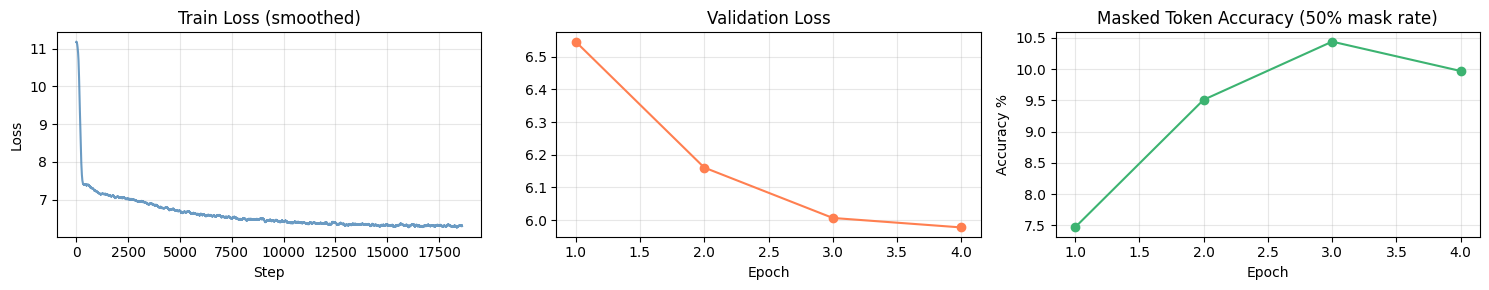


Final val loss     : 5.9775
Best  val loss     : 5.9775
Final mask accuracy: 10.0%  (at 50% mask rate)


In [12]:
# ── Cell 7: Training Curves ───────────────────────────────────────────────────
window = 100
smoothed = [np.mean(train_losses[max(0,i-window):i+1]) for i in range(len(train_losses))]

fig, axes = plt.subplots(1, 3, figsize=(15, 3))

axes[0].plot(smoothed, color="steelblue", alpha=0.8)
axes[0].set_title("Train Loss (smoothed)")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(val_losses)+1), val_losses, "o-", color="coral")
axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch"); axes[1].grid(True, alpha=0.3)

axes[2].plot(range(1, len(val_accs)+1), val_accs, "o-", color="mediumseagreen")
axes[2].set_title("Masked Token Accuracy (50% mask rate)")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Accuracy %")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal val loss     : {val_losses[-1]:.4f}")
print(f"Best  val loss     : {best_val_loss:.4f}")
print(f"Final mask accuracy: {val_accs[-1]:.1f}%  (at 50% mask rate)")

In [13]:
# ── Cell 8: Load Best Checkpoint ─────────────────────────────────────────────
model.load_state_dict(torch.load("best_hindiff.pt", map_location=device))
model.eval()
print("Loaded best checkpoint.")

Loaded best checkpoint.


In [14]:
# ── Cell 9: Demo — Text Infilling ─────────────────────────────────────────────
# This is diffusion's unique strength: fill in ANY masked span, not just the end.

@torch.no_grad()
def infill(sentence, mask_fraction=0.4, num_steps=GEN_STEPS, temperature=GEN_TEMP):
    """
    Mask `mask_fraction` of a real Hindi sentence, then iteratively restore it.
    Returns the filled-in text and shows how confident the model was.
    """
    model.eval()
    ids      = tokenizer.encode(sentence, add_special_tokens=False)[:MAX_LEN]
    real_len = len(ids)
    pad_len  = MAX_LEN - real_len
    ids_pad  = ids + [PAD_ID] * pad_len

    x        = torch.tensor([ids_pad], dtype=torch.long, device=device)
    real_pos = torch.zeros(1, MAX_LEN, dtype=torch.bool, device=device)
    real_pos[0, :real_len] = True

    # Choose which positions to mask
    n_mask  = max(1, int(real_len * mask_fraction))
    perm    = torch.randperm(real_len)[:n_mask]
    masked_pos = torch.zeros(1, MAX_LEN, dtype=torch.bool, device=device)
    masked_pos[0, perm] = True

    x_in    = x.clone()
    x_in[masked_pos] = MASK_ID

    # Show input
    in_tokens = x_in[0, :real_len].tolist()
    in_text   = tokenizer.decode([t if t != MASK_ID else tokenizer.unk_token_id
                                  for t in in_tokens])
    print(f"  Original : {sentence[:90]}")
    print(f"  Masked   : {in_text[:90]}  [{n_mask} tokens hidden]")

    # Iterative unmasking
    pad_mask = ~real_pos
    for step in range(num_steps):
        t_noise = 1.0 - (step + 1) / num_steps
        logits  = model(x_in, pad_mask=pad_mask) / temperature
        probs   = F.softmax(logits, dim=-1)
        sampled = torch.multinomial(probs.view(-1, VOCAB_SIZE), 1).view(1, MAX_LEN)

        still_masked = (x_in == MASK_ID) & real_pos
        if not still_masked.any():
            break

        confidence = probs.max(dim=-1).values        # (1, L)
        confidence[~still_masked] = -1.0

        n_still  = still_masked.sum().item()
        n_keep   = int(max(0.0, t_noise) * n_mask)
        n_unmask = max(1, n_still - n_keep)

        _, top = confidence.view(-1).topk(min(n_unmask, n_still))
        x_in.view(-1)[top] = sampled.view(-1)[top]

    # Fill any remaining masks (shouldn't happen, but safety net)
    still = (x_in == MASK_ID) & real_pos
    if still.any():
        logits  = model(x_in, pad_mask=pad_mask)
        probs   = F.softmax(logits / temperature, dim=-1)
        final   = torch.multinomial(probs.view(-1, VOCAB_SIZE), 1).view(1, MAX_LEN)
        x_in[still] = final[still]

    out_text = tokenizer.decode(x_in[0, :real_len].tolist(), skip_special_tokens=True)

    # Accuracy on masked positions
    orig_ids = torch.tensor(ids, device=device)
    filled   = x_in[0, :real_len]
    acc = (filled[perm] == orig_ids[perm]).float().mean().item() * 100
    print(f"  Restored : {out_text[:90]}")
    print(f"  Token accuracy on masked positions : {acc:.0f}%\n")
    return out_text


print("=" * 65)
print("  INFILLING DEMO  — 40% of tokens hidden then restored")
print("=" * 65 + "\n")

test_sentences = [
    "भारत एक लोकतांत्रिक देश है जहाँ सभी नागरिकों को समान अधिकार मिलते हैं।",
    "आज का मौसम बहुत सुहाना है और आसमान में बादल छाए हुए हैं।",
    "शिक्षा के बिना जीवन में सफलता प्राप्त करना बहुत कठिन होता है।",
    "प्रधानमंत्री ने देश की जनता को संबोधित करते हुए कहा कि हम सब मिलकर आगे बढ़ेंगे।",
    "दिल्ली भारत की राजधानी है और यहाँ लाखों लोग रहते हैं।",
]
for sent in test_sentences:
    infill(sent, mask_fraction=0.4)

  INFILLING DEMO  — 40% of tokens hidden then restored

  Original : भारत एक लोकतांत्रिक देश है जहाँ सभी नागरिकों को समान अधिकार मिलते हैं।
  Masked   : भारत<unk><unk>तांत्रिक देश है<unk><unk> नागरिकों को समान<unk> मिलते<unk>।  [6 tokens hidden]
  Restored : भारत के लिएतांत्रिक देश है और इस नागरिकों को समान घोषणा मिलते हैं।
  Token accuracy on masked positions : 17%

  Original : आज का मौसम बहुत सुहाना है और आसमान में बादल छाए हुए हैं।
  Masked   : आज का मौसम<unk> सु<unk><unk> है<unk><unk><unk> बादल छाए हुए हैं।  [6 tokens hidden]
  Restored : आज का मौसम. सुश होती है, जो अपने बादल छाए हुए हैं।
  Token accuracy on masked positions : 0%

  Original : शिक्षा के बिना जीवन में सफलता प्राप्त करना बहुत कठिन होता है।
  Masked   : शिक्षा के<unk><unk><unk> सफलता प्राप्त<unk> बहुत कठिन होता है<unk>  [5 tokens hidden]
  Restored : शिक्षा के लिए दिल्ली में सफलता प्राप्त करते बहुत कठिन होता है।
  Token accuracy on masked positions : 40%

  Original : प्रधानमंत्री ने देश की जनता को संबोधित करते हुए क

In [15]:
# ── Cell 10: Demo — Generation from Pure Noise ────────────────────────────────
# Start with ALL tokens masked. Iteratively unmask using the model's predictions.
# This is the core generative capability unique to diffusion models.

@torch.no_grad()
def generate(num_steps=GEN_STEPS, temperature=GEN_TEMP, length=None,
             show_steps=False):
    """
    Generate a Hindi sentence by starting from all-[MASK] and iteratively
    unmasking from highest to lowest confidence.

    `length` : how many tokens to generate (default: MAX_LEN)
    `show_steps` : print intermediate demasking steps
    """
    model.eval()
    gen_len = length or MAX_LEN

    # All masks
    x       = torch.full((1, gen_len), MASK_ID, dtype=torch.long, device=device)
    pad_mask = torch.zeros(1, gen_len, dtype=torch.bool, device=device)  # no padding

    step_texts = []
    for step in range(num_steps):
        t_noise = 1.0 - (step + 1) / num_steps
        logits  = model(x, pad_mask=pad_mask) / temperature
        probs   = F.softmax(logits, dim=-1)
        sampled = torch.multinomial(probs.view(-1, VOCAB_SIZE), 1).view(1, gen_len)

        masked = (x == MASK_ID)
        if not masked.any():
            break

        confidence = probs.max(dim=-1).values
        confidence[~masked] = -1.0

        n_still  = masked.sum().item()
        n_keep   = int(max(0.0, t_noise) * gen_len)
        n_unmask = max(1, n_still - n_keep)

        _, top = confidence.view(-1).topk(min(n_unmask, n_still))
        x.view(-1)[top] = sampled.view(-1)[top]

        if show_steps and (step % (num_steps // 6) == 0 or step == num_steps - 1):
            partial = [t if t != MASK_ID else tokenizer.unk_token_id
                       for t in x[0].tolist()]
            step_texts.append((step + 1, tokenizer.decode(partial, skip_special_tokens=True)))

    # Final fill
    still = (x == MASK_ID)
    if still.any():
        logits = model(x, pad_mask=pad_mask)
        probs  = F.softmax(logits / temperature, dim=-1)
        final  = torch.multinomial(probs.view(-1, VOCAB_SIZE), 1).view(1, gen_len)
        x[still] = final[still]

    out = tokenizer.decode(x[0].tolist(), skip_special_tokens=True)
    if show_steps:
        for step_no, text in step_texts:
            print(f"  step {step_no:3d} : {text[:80]}")
    return out


print("=" * 65)
print("  GENERATION DEMO — Hindi text from pure noise")
print("=" * 65 + "\n")

print("--- One generation with step-by-step unmasking ---")
gen = generate(show_steps=True)
print(f"\n  Final : {gen}\n")

print("--- 8 independent samples (length = 32 tokens) ---")
for i in range(8):
    g = generate(length=32, temperature=GEN_TEMP + i * 0.05)
    print(f"  {i+1}. {g}")

  GENERATION DEMO — Hindi text from pure noise

--- One generation with step-by-step unmasking ---
  step   1 : तकम्प
  step   9 : तकम्प के बाद व्यक्ति के करने को होना जाता है.
  step  17 : तकम्प के बाद है और एक से मुलाकात के साथ युद्ध से व्यक्ति के लिए करने को होना जात
  step  25 : तकम्प के बाद मेंना योजना का कदम से फरवरी है और एक से मुलाकात के साथ इस बेटे, युद
  step  33 : तकम्प के बाद के रूप मेंना काम है कि मुझे से योजना का कदम से फरवरी है और एक� करने
  step  41 : तकम्प के बाद के रूप में सभीनाने का काम है कि मुझे से योजना का कदम से फरवरी है और
  step  49 : तकम्प के बाद के रूप में सभीनाने का काम है कि मुझे एक अनुबंध से योजना का कदम से फ
  step  50 : तकम्प के बाद के रूप में सभीोकनाने का काम है कि मुझे एक अनुबंध से योजना का कदम से

  Final : तकम्प के बाद के रूप में सभीोकनाने का काम है कि मुझे एक अनुबंध से योजना का कदम से फरवरी है और एक एक टा���� करने के उपयोगों से मुलाकात के साथ इस बेटे, युद्ध से व्यक्ति के लिए काम की एक बारे में जमा कोल ले करने को होना जाता है.

--- 8 independent samp

Evaluating accuracy at different mask rates …

  mask  10%  →  accuracy 21.3%
  mask  20%  →  accuracy 17.6%
  mask  30%  →  accuracy 17.4%
  mask  40%  →  accuracy 15.6%
  mask  50%  →  accuracy 14.5%
  mask  60%  →  accuracy 13.2%
  mask  70%  →  accuracy 11.7%
  mask  80%  →  accuracy 10.2%
  mask  90%  →  accuracy 8.8%


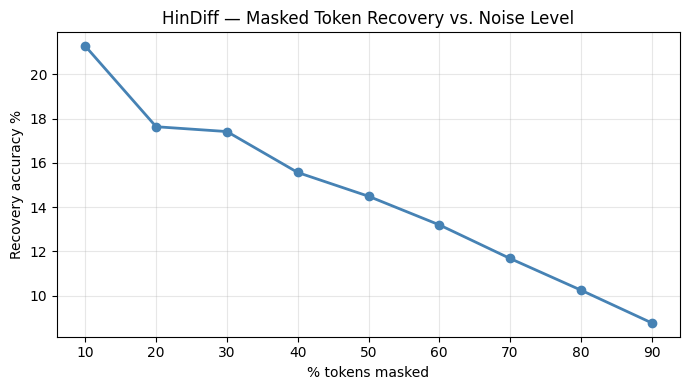

In [16]:
# ── Cell 11: Accuracy Across Noise Levels ────────────────────────────────────
# Show how accuracy degrades as more tokens are masked — this curve characterises
# how well the model has learned Hindi token distributions.

print("Evaluating accuracy at different mask rates …\n")

mask_rates   = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
rate_accs    = []
EVAL_N       = 500    # sentences to evaluate per rate

eval_sents   = test_sents[:EVAL_N]
eval_ids     = []
for s in eval_sents:
    ids = tokenizer.encode(s, add_special_tokens=False)[:MAX_LEN]
    if len(ids) >= 4:
        pad = [PAD_ID] * (MAX_LEN - len(ids))
        eval_ids.append((ids, len(ids)))

model.eval()
with torch.no_grad():
    for rate in mask_rates:
        correct, total = 0, 0
        for ids, rlen in eval_ids:
            x_orig = torch.tensor(ids + [PAD_ID]*(MAX_LEN-len(ids)),
                                  dtype=torch.long, device=device).unsqueeze(0)
            real   = torch.zeros(1, MAX_LEN, dtype=torch.bool, device=device)
            real[0, :rlen] = True

            n_mask = max(1, int(rlen * rate))
            perm   = torch.randperm(rlen, device=device)[:n_mask]
            nm     = torch.zeros(1, MAX_LEN, dtype=torch.bool, device=device)
            nm[0, perm] = True

            x_in = x_orig.clone(); x_in[nm] = MASK_ID
            with torch.amp.autocast("cuda"):
                logits = model(x_in, pad_mask=~real)
            preds = logits.argmax(-1)
            correct += ((preds == x_orig) & nm).sum().item()
            total   += nm.sum().item()

        acc = correct / max(total, 1) * 100
        rate_accs.append(acc)
        print(f"  mask {int(rate*100):3d}%  →  accuracy {acc:.1f}%")

plt.figure(figsize=(7, 4))
plt.plot([r*100 for r in mask_rates], rate_accs, "o-", color="steelblue", lw=2)
plt.xlabel("% tokens masked"); plt.ylabel("Recovery accuracy %")
plt.title("HinDiff — Masked Token Recovery vs. Noise Level")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [17]:
# ── Cell 12: Save Model ───────────────────────────────────────────────────────
import shutil

save_path = "hindiff_hindi_mdlm.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "config": {
        "d_model": D_MODEL, "n_heads": N_HEADS,
        "n_layers": N_LAYERS, "d_ff": D_FF,
        "max_len": MAX_LEN, "vocab_size": VOCAB_SIZE,
        "total_vocab": TOTAL_VOCAB, "mask_id": MASK_ID, "pad_id": PAD_ID,
    },
    "tokenizer": "sarvamai/sarvam-1",
    "val_loss": best_val_loss,
    "val_acc_50pct_mask": val_accs[-1],
}, save_path)

size_mb = os.path.getsize(save_path) / 1e6
print(f"Saved  : {save_path}  ({size_mb:.1f} MB)")
print(f"Val loss (best)   : {best_val_loss:.4f}")
print(f"Mask accuracy 50% : {val_accs[-1]:.1f}%")

try:
    from google.colab import files
    files.download(save_path)
except ImportError:
    print("(Not in Colab — saved locally)")

Saved  : hindiff_hindi_mdlm.pt  (82.4 MB)
Val loss (best)   : 5.9775
Mask accuracy 50% : 10.0%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>